<div style="padding: 1em 0.5em; color: #fff; background-color: #0969da; font-size: 1.2em;">
    Jour 2 — Embeddings Evo2 + classifieur (le « teacher »)
</div>
<div style="border-left: 2px solid #0969da; min-height: 1.5em;margin-left: 1em;padding: 1em;">
    - Charger les embeddings Evo2 pré-calculés et visualiser l'espace de représentation (PCA) avant tout entraînement<br>
    - Entraîner une petite tête MLP sur ces embeddings gelés : c'est notre modèle « teacher »<br>
    - Mesurer le gain de précision face aux références du Jour 1, et son coût (dépendance à un modèle de 7 milliards de paramètres)<br>
</div>

#### **Votre identité**

Double-cliquez sur cette cellule et complétez, puis exécutez-la (`Maj + Entrée`).

- **Nom & prénom :** _à compléter_
- **Groupe / binôme :** _à compléter_
- **Date :** _à compléter_

<div style="height: 3px; margin: 2em 0 1.5em 0; background: linear-gradient(90deg, #0969da 0%, #0969da 55%, rgba(9,105,218,0.15) 100%);"></div>

**Evo2** est un grand modèle de fondation pour l'ADN (architecture StripedHyena2) entraîné
sur des génomes à travers l'arbre du vivant. Plutôt que de concevoir des caractéristiques à
la main (k-mers) ou de les apprendre à partir de zéro sur notre petit jeu de données (le
CNN), on peut demander à un modèle qui a déjà « lu » une énorme quantité d'ADN de
représenter nos fenêtres pour nous.

Nous accédons à Evo2 via l'**API hébergée par NVIDIA** plutôt qu'en exécutant nous-mêmes
le modèle à 7 milliards de paramètres. Les organisateurs ont déjà appelé l'API sur chaque
fenêtre étiquetée issue de `01_kmer_and_cnn_baselines.ipynb` et sauvegardé les résultats —
c'est le plus grand levier de faisabilité de la semaine : vous n'attendez jamais un appel
API en direct.

<img src="https://raw.githubusercontent.com/Genereux-akotenou/EEIA-bioAI-Workshop-project/main/day2/assets/pretrained_paradigm.png"/>

---

Le modèle de fondation que nous utiliserons ici est **Evo2**. Il a été pré-entraîné sur de
grandes quantités de séquences d'ADN issues de génomes de tout l'arbre du vivant. L'idée est
la même que celle de ChatGPT — apprendre à prédire la suite d'une séquence — mais appliquée
au langage du vivant plutôt qu'au texte.

Pour les plus curieux, voici quelques ressources complémentaires. **Leur lecture n'est pas
nécessaire pour atteindre les objectifs de la journée.**

- [Evo2 expliqué en vidéo](https://www.youtube.com/watch?v=o_w-E--u7GQ)
- [Le dépôt GitHub d'Evo2](https://github.com/arcinstitute/evo2)
- [La page officielle du projet (Arc Institute)](https://arcinstitute.org/tools/evo)


In [34]:
# --- Préparation des données (une seule fois) -------------------------------
# Les embeddings Evo2 viennent de l'API. S'ils sont déjà là, on ne fait rien.
import os, subprocess, sys
from pathlib import Path


# Si le notebook tourne depuis la racine du projet
if Path("2-data/raw").exists():
    RAW_DIR = "2-data/raw"
    if "day1/src" not in sys.path:
        sys.path.append("day1/src")
# Si le notebook tourne depuis le dossier day1/
else:
    RAW_DIR = "../2-data/raw"
    if "src" not in sys.path:
        sys.path.append("src")

print(f"Dossier raw utilisé : {RAW_DIR}")


DATA = Path("../2-data")

if (DATA / "embeddings" / "train.npz").exists():
    print("OK   embeddings Evo2 — déjà présents")
elif not os.environ.get("NVIDIA_API_KEY"):
    raise RuntimeError(
        "Embeddings manquants, et NVIDIA_API_KEY n'est pas défini.\n"
        "  export NVIDIA_API_KEY=nvapi-...   puis relancez cette cellule,\n"
        "  ou demandez les données pré-extraites à l'encadrant."
    )
else:
    print("...  extraction des embeddings Evo2 — compter ~4 s par fenêtre")
    subprocess.run([sys.executable, "extract_evo2_embeddings.py",
                    "--processed_dir", "./processed", "--out_dir", "./embeddings",
                    "--max_per_split", "train=4000", "val=1000", "test=1000",
                    "--target_layers", "blocks.26", "blocks.31"],
                   cwd=DATA, check=True)
    print("OK   embeddings extraits")

Dossier raw utilisé : ../2-data/raw
OK   embeddings Evo2 — déjà présents


In [2]:
import sys
sys.path.append("src")

import torch
from embeddings import load_supervised_embeddings,available_layers
from models.classifier_heads import MLPHead
from eval import evaluate_logits, count_params, measure_latency_torch
from viz import plot_embedding_space

EMB_DIR = "../2-data/embeddings"

X_train, y_train, ids_train = load_supervised_embeddings(EMB_DIR, 'train')
X_val, y_val, ids_val =  load_supervised_embeddings(EMB_DIR, 'val')
print("embedding dim:", X_train.shape[1], "| train windows:", X_train.shape[0])
print(available_layers(EMB_DIR, "train"))


embedding dim: 4096 | train windows: 4000
['blocks.26', 'blocks.31']


<div style="height: 3px; margin: 2em 0 1.5em 0; background: linear-gradient(90deg, #0969da 0%, #0969da 55%, rgba(9,105,218,0.15) 100%);"></div>

#### **Visualisons l'espace des embeddings avant d'entraîner quoi que ce soit**

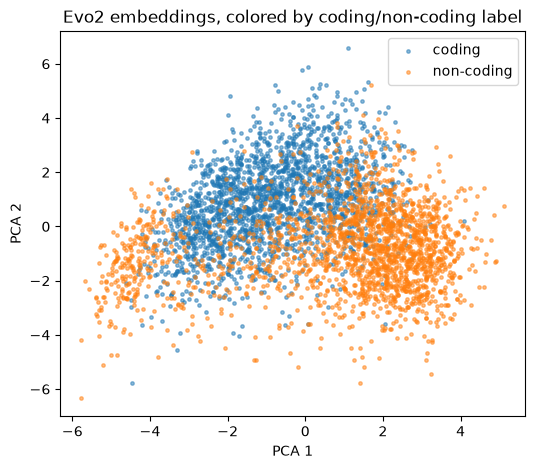

array([[-3.187419  , -2.8439586 ],
       [-1.2257829 ,  2.2374783 ],
       [ 0.5086407 ,  1.1850593 ],
       ...,
       [ 2.1909366 , -2.2419426 ],
       [-2.27465   , -0.6437256 ],
       [-3.5870645 , -0.66538286]], shape=(4000, 2), dtype=float32)

In [3]:
# TODO : appelez plot_embedding_space sur les embeddings d'entraînement (method="pca")
# avec un titre du type "Evo2 embeddings, colored by coding/non-coding label"
 
plot_embedding_space(
    embeddings=X_train,
    labels=y_train,
    method="pca",
    title="Evo2 embeddings, colored by coding/non-coding label"
)


#### **Entraînons le teacher : une petite tête MLP sur les embeddings gelés**

In [5]:
# N_EPOCHS : même budget d'entraînement pour TOUS les modèles de la semaine,
# pour que la comparaison du Jour 4 porte sur la représentation et non sur
# la durée d'entraînement. Modifiable ici.
N_EPOCHS = 100

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)

# TODO : instanciez MLPHead(d_in=X_train.shape[1]) et un optimiseur Adam (lr=1e-3)
teacher = MLPHead(d_in=X_train.shape[1])
print(teacher)
optimizer = torch.optim.Adam(teacher.parameters(), lr=1e-3)

n = X_train_t.shape[0]

criterion= torch.nn.BCEWithLogitsLoss()
for epoch in range(N_EPOCHS):
    perm = torch.randperm(n)
    epoch_loss = 0.0
    for start in range(0, n, 256):
        idx = perm[start:start + 256]
        optimizer.zero_grad()
        # TODO : logits du teacher sur ce mini-lot, puis perte BCE-with-logits
        logits = teacher(X_train_t[idx])
        loss = criterion(logits, y_train_t[idx])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1}/{N_EPOCHS}: loss={epoch_loss/n:.4f}")

MLPHead(
  (net): Sequential(
    (0): Linear(in_features=4096, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
epoch 5/100: loss=0.0681
epoch 10/100: loss=0.0541
epoch 15/100: loss=0.0484
epoch 20/100: loss=0.0419
epoch 25/100: loss=0.0341
epoch 30/100: loss=0.0361
epoch 35/100: loss=0.0237
epoch 40/100: loss=0.0181
epoch 45/100: loss=0.0136
epoch 50/100: loss=0.0105
epoch 55/100: loss=0.0094
epoch 60/100: loss=0.0067
epoch 65/100: loss=0.0063
epoch 70/100: loss=0.0047
epoch 75/100: loss=0.0063
epoch 80/100: loss=0.0024
epoch 85/100: loss=0.0023
epoch 90/100: loss=0.0017
epoch 95/100: loss=0.0015
epoch 100/100: loss=0.0012


In [31]:
# TODO : évaluez le teacher sur validation (sans gradient), puis calculez metrics/params/latence
with torch.no_grad():
    val_logits = teacher(X_val_t).numpy()
teacher_metrics = evaluate_logits(val_logits, y_val)

print("Evo2 embeddings + MLP teacher:", teacher_metrics)
print("params:", ..., "| latency (ms/sample):", ...)

Evo2 embeddings + MLP teacher: {'accuracy': 0.958, 'f1': 0.958498023715415}
params: Ellipsis | latency (ms/sample): Ellipsis


#### **Sauvegardons le teacher pour le Jour 3**

La distillation du Jour 3 a besoin de *ce* teacher entraîné. On enregistre ses poids sur
disque pour ne pas avoir à le ré-entraîner demain.

In [33]:
from pathlib import Path

# poids + dimension d'entrée (nécessaire pour reconstruire l'architecture au Jour 3)
MODEL_DIR = Path("../2-data/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
torch.save({"state_dict": teacher.state_dict(), "d_in": X_train.shape[1]},
           MODEL_DIR / "teacher_mlp.pt")
print("teacher sauvegardé ->", MODEL_DIR / "teacher_mlp.pt")

teacher sauvegardé -> ../2-data/models/teacher_mlp.pt


#### **Point de contrôle**

Comparez `teacher_metrics` au tableau `comparison` du Jour 1 — les embeddings Evo2
devraient donner un gain de précision visible, et le graphique PCA devrait déjà montrer
une certaine séparation des clusters par étiquette, même si les embeddings n'ont jamais
été affinés pour cette tâche.

Les poids du teacher sont maintenant dans `2-data/models/teacher_mlp.pt` : le notebook 03
les rechargera directement. Ses prédictions y deviendront les cibles douces (*soft targets*)
de la distillation.

Suite : `03_knowledge_distillation.ipynb`.

*Bloqué ? La version complète est dans `solution/02_evo2_embeddings_and_classifier.ipynb`.*

<div style="margin-top: 3em;">
  <div style="height: 3px; background: linear-gradient(90deg, #0969da 0%, #0969da 55%, rgba(9,105,218,0.15) 100%);"></div>
  <div style="display: flex; align-items: center; gap: 0.9em; padding: 1.1em 1em; font-size: 0.9em; color: #57606a; background-color: #f2f6fd; border-radius: 0 0 6px 6px;">
    <svg width="34" height="34" viewBox="0 0 34 34" fill="none" style="flex: 0 0 auto;">
      <path d="M9 3c0 7 16 7 16 14S9 24 9 31" stroke="#0969da" stroke-width="2" stroke-linecap="round"/>
      <path d="M25 3c0 7-16 7-16 14s16 7 16 14" stroke="#0969da" stroke-width="2" stroke-linecap="round" opacity="0.45"/>
      <circle cx="17" cy="10" r="1.8" fill="#0969da"/>
      <circle cx="17" cy="24" r="1.8" fill="#0969da"/>
    </svg>
    <div style="flex: 1 1 auto;">
      <div style="color: #0969da; font-weight: 600; letter-spacing: 0.03em;">Fin du Jour 2</div>
      <div>Prochaine &eacute;tape &rarr; <code>day3/03_knowledge_distillation.ipynb</code></div>
    </div>
    <div style="flex: 0 0 auto; text-align: right; border-right: 2px solid #0969da; padding-right: 0.9em;">
      <div style="font-weight: 600; color: #24292f;">EEIA &middot; bioAI Workshop</div>
      <div style="font-size: 0.85em;">Semaine 4 &mdash; De l'ADN aux mod&egrave;les compress&eacute;s</div>
    </div>
  </div>
</div>

Viewed classifier_heads.py:1-31

Voici la leçon détaillée sur **ce que font ces deux lignes** et **comment les écrire**.

---

# 📚 Le cours : Que se passe-t-il dans un mini-lot (*mini-batch*) ?

Dans la boucle d'entraînement, nous ne traitons pas tout le jeu de données d'un coup. Nous le découpons en petits paquets de 256 échantillons (**mini-batches**) pour économiser la mémoire et accélérer les calculs.

À chaque itération de la boucle :
- `idx` contient les 256 indices sélectionnés au hasard (ex: `[42, 105, 7, ...]`).
- `X_train_t[idx]` est notre sous-ensemble d'embeddings d'entrée, de forme **`(256, 4096)`**.
- `y_train_t[idx]` est notre sous-ensemble d'étiquettes réelles (0 ou 1), de forme **`(256,)`**.

---

## 1. Ligne 1 : `logits = ...` (Le passage Forward)

### 🎯 Le But :
Demander au modèle `teacher` de prédire un score pour chacune des 256 séquences ADN du mini-lot.

### 🔍 Comment ça marche ?
En PyTorch, pour faire passer des données à travers un modèle, on appelle directement l'objet comme une fonction : `teacher(données)`.
Cela déclenche automatiquement la méthode `forward()` que vous avez définie dans `MLPHead`.

```python
logits = teacher(X_train_t[idx])
```

### 📊 Résultat obtenu :
`logits` est un tenseur 1D de forme **`(256,)`** contenant 256 nombres réels (les scores bruts du modèle pour ce mini-lot).

---

## 2. Ligne 2 : `loss = ...` (Le calcul de la perte)

### 🎯 Le But :
Mesurer à quel point le modèle s'est trompé sur ce mini-lot en comparant ses prédictions (`logits`) avec la réalité (`y_train_t[idx]`).

### 🔍 Quelle fonction de perte utiliser pour de la classification binaire ?

Pour un problème binaire (0 ou 1) où le modèle produit des **logits bruts** (sans Sigmoïde intégrée dans le réseau), on utilise l'**Entropie Croisée Binaire avec Logits** : **`BCEWithLogitsLoss`**.

#### Pourquoi "With Logits" ?
Mathématiquement, pour transformer un logit $z$ en probabilité $p$, on applique la Sigmoïde :
$$p = \frac{1}{1 + e^{-z}}$$
Puis on calcule le logarithme de la probabilité $\ln(p)$.

Si on calcule Sigmoïde puis Logarithme séparément en informatique, les nombres très grands ou très petits provoquent des erreurs d'arrondi (ex: `log(0) = -infinity` ou crash numérique). 
`BCEWithLogitsLoss` combine la Sigmoïde et la Binary Cross Entropy en **une seule formule mathématique très stable**.

### 💻 Deux manières d'écrire la perte :

#### Option A (Recommandée : Définir la perte avant la boucle) :
Avant la boucle `for`, on instancie le critère :
```python
criterion = nn.BCEWithLogitsLoss()
```
Puis dans la boucle :
```python
loss = criterion(logits, y_train_t[idx])
```

#### Option B (Directe avec le module fonctionnel de PyTorch) :
Directement dans la boucle :
```python
import torch.nn.functional as F

loss = F.binary_cross_entropy_with_logits(logits, y_train_t[idx])
```

---

## 📐 Résumé des formes des données :

| Variable | Description | Forme (*Shape*) |
| :--- | :--- | :--- |
| `X_train_t[idx]` | Embeddings d'entrée du batch | `(256, 4096)` |
| `logits` | Prédictions brutes du modèle | `(256,)` |
| `y_train_t[idx]` | Vraies réponses (0 ou 1) | `(256,)` |
| `loss` | Note d'erreur globale du batch (scalaire) | Un seul nombre (ex: `0.6834`) |

---

Est-ce que le rôle des `logits`, de `y_train_t[idx]` et de `BCEWithLogitsLoss` est clair ? Préférez-vous essayer de compléter ces deux lignes vous-même dans le notebook ?